In [1]:
import os, sys 
from pathlib import Path
from os.path import dirname, realpath
script_dir = Path(dirname(realpath('.')))
module_dir = str(script_dir)
sys.path.insert(0, module_dir + '/modules')
import numpy as np
import utility as ut
import matplotlib.pyplot as plt
import pandas as pd
import warnings
from scipy import stats
import seaborn as sns
import sample as sm
import eulerSnake as arch 
import torch
# warnings.filterwarnings('ignore')

In [2]:
Uo1 = np.load('../data/L63-trajectories/train1.npy')
Uo2 = np.load('../data/L63-trajectories/train2.npy')
Uo3 = np.load('../data/L63-trajectories/train3.npy')
Uo4 = np.load('../data/L63-trajectories/train4.npy')
Uo5 = np.load('../data/L63-trajectories/train5.npy')
Uo6 = np.load('../data/L63-trajectories/train6.npy')
Uo7 = np.load('../data/L63-trajectories/train7.npy')
Uo8 = np.load('../data/L63-trajectories/train8.npy')
Uo9 = np.load('../data/L63-trajectories/train9.npy')
Uo10 = np.load('../data/L63-trajectories/train10.npy')

Vo = np.load('../data/L63-trajectories/test.npy')
L0, L1 = 0.4, 3.5
D, D_r, B = 3, 256, 2
beta = 4e-5
m = 100

In [3]:
B = 1
rf1 = arch.DeepRF(D_r, B, L0, L1, Uo1, beta, name='test', save_folder='../data/eulerN')
rf1.init()
tau1 = rf1.compute_tau_f_(Vo[0:m])

Time taken by sample is 0.0047 seconds
Time taken by sample is 0.0061 seconds
Time taken by compute_tau_f_ is 2.8341 seconds


In [4]:
B = 2
rf2 = arch.DeepRF(D_r, B, L0, L1, Uo2, beta, name='test', save_folder='../data/eulerN')
rf2.init()
tau2 = rf2.compute_tau_f_(Vo[0:m])

Time taken by sample is 0.0046 seconds
Time taken by sample is 0.0047 seconds
Time taken by sample is 0.0051 seconds
Time taken by sample is 0.0126 seconds
Time taken by compute_tau_f_ is 5.0964 seconds


In [5]:
B = 3
rf3 = arch.DeepRF(D_r, B, L0, L1, Uo3, beta, name='test', save_folder='../data/eulerN')
rf3.init()
tau3 = rf3.compute_tau_f_(Vo[0:m])

Time taken by sample is 0.0046 seconds
Time taken by sample is 0.0045 seconds
Time taken by sample is 0.0048 seconds
Time taken by sample is 0.0116 seconds
Time taken by sample is 0.0048 seconds
Time taken by sample is 0.0125 seconds
Time taken by compute_tau_f_ is 7.3325 seconds


In [6]:
B = 10
rf10 = arch.DeepRF(D_r, B, L0, L1, Uo10, beta, name='test', save_folder='../data/eulerN')
rf10.init()
tau10 = rf10.compute_tau_f_(Vo[0:m])

Time taken by sample is 0.0048 seconds
Time taken by sample is 0.0067 seconds
Time taken by sample is 0.0130 seconds
Time taken by sample is 0.0125 seconds
Time taken by sample is 0.0093 seconds
Time taken by sample is 0.0127 seconds
Time taken by sample is 0.0047 seconds
Time taken by sample is 0.0131 seconds
Time taken by sample is 0.0049 seconds
Time taken by sample is 0.0157 seconds
Time taken by sample is 0.0047 seconds
Time taken by sample is 0.0119 seconds
Time taken by sample is 0.0048 seconds
Time taken by sample is 0.0076 seconds
Time taken by sample is 0.0047 seconds
Time taken by sample is 0.0114 seconds
Time taken by sample is 0.0047 seconds
Time taken by sample is 0.0125 seconds
Time taken by sample is 0.0048 seconds
Time taken by sample is 0.0133 seconds
Time taken by compute_tau_f_ is 24.3849 seconds


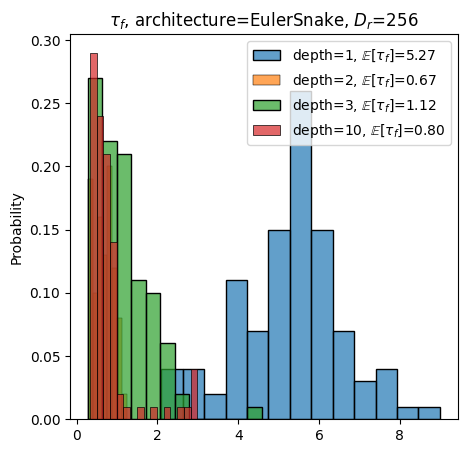

In [7]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
sns.histplot(tau1[1], ax=ax, label=r'depth=1, $\mathbb{E}[\tau_f]$'+f'={tau1[1].mean():.2f}', alpha=0.7, stat='probability')
sns.histplot(tau2[1], ax=ax, label=r'depth=2, $\mathbb{E}[\tau_f]$'+f'={tau2[1].mean():.2f}', alpha=0.7, stat='probability')
sns.histplot(tau3[1], ax=ax, label=r'depth=3, $\mathbb{E}[\tau_f]$'+f'={tau3[1].mean():.2f}', alpha=0.7, stat='probability')
sns.histplot(tau10[1], ax=ax, label=r'depth=10, $\mathbb{E}[\tau_f]$'+f'={tau10[1].mean():.2f}', alpha=0.7, stat='probability')
ax.legend()
ax.set_title(fr'$\tau_f$, architecture=EulerSnake, $D_r$={D_r}')
plt.savefig(f'../data/plots/eulerSnake-tau_f-D_r-{D_r}.png', bbox_inches='tight', dpi=300)